In [43]:
import pandas as pd

df = pd.read_csv("datasets/superstore.csv")
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [44]:
df.shape
df.columns
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9983 non-null   float64
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9983.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55245.233297,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32038.715955,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,57103.000000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [45]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])


In [46]:
df[['Order Date','Ship Date']].head()


,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


C:\Users\deenu\AppData\Local\Temp\ipykernel_25924\1667992323.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample('M', on='Order Date')['Sales'].sum()


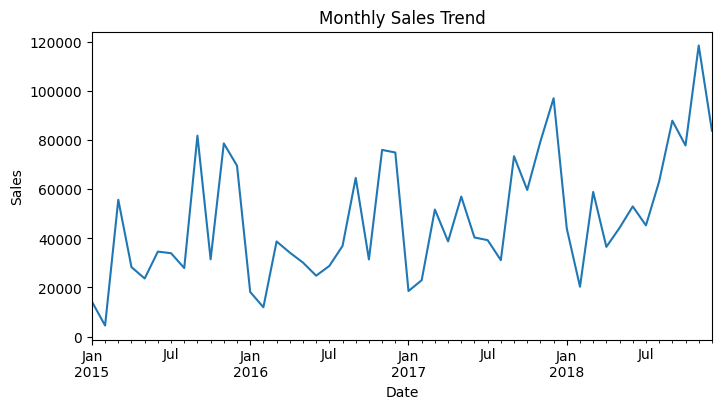

In [47]:
monthly_sales = df.resample('M', on='Order Date')['Sales'].sum()

import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()


In [48]:
plt.savefig("visualizations/monthly_sales.png", dpi=300, bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

C:\Users\deenu\AppData\Local\Temp\ipykernel_25924\246786425.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_profit = df.resample('M', on='Order Date')['Profit'].sum()


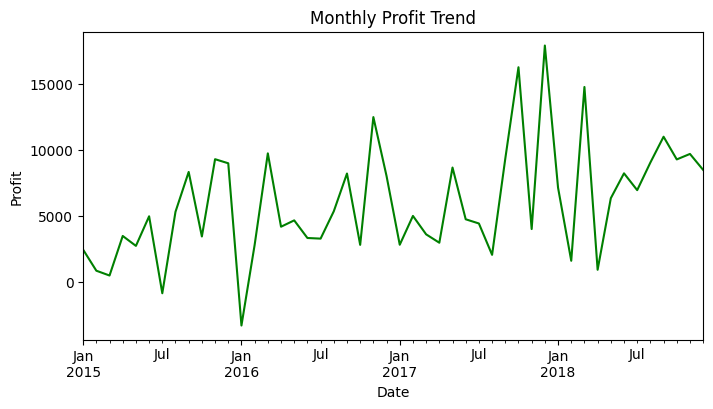

<Figure size 640x480 with 0 Axes>

In [49]:
monthly_profit = df.resample('M', on='Order Date')['Profit'].sum()

plt.figure(figsize=(8,4))
monthly_profit.plot(color='green')
plt.title("Monthly Profit Trend")
plt.xlabel("Date")
plt.ylabel("Profit")
plt.show()

plt.savefig("visualizations/monthly_profit.png", dpi=300, bbox_inches='tight')


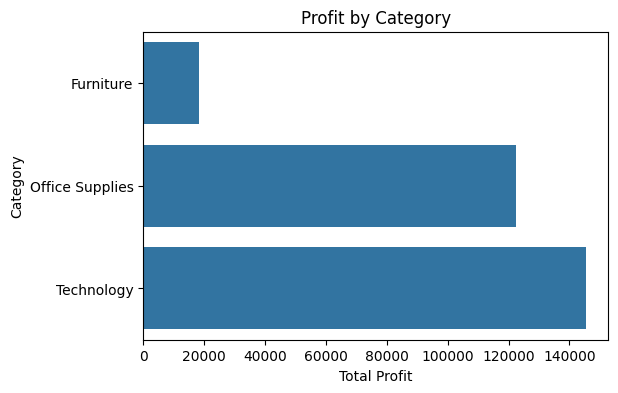

<Figure size 640x480 with 0 Axes>

In [50]:
import seaborn as sns

category_profit = df.groupby('Category')['Profit'].sum().sort_values()

plt.figure(figsize=(6,4))
sns.barplot(x=category_profit.values, y=category_profit.index)
plt.title("Profit by Category")
plt.xlabel("Total Profit")
plt.ylabel("Category")
plt.show()

plt.savefig("visualizations/profit_by_category.png", dpi=300, bbox_inches='tight')


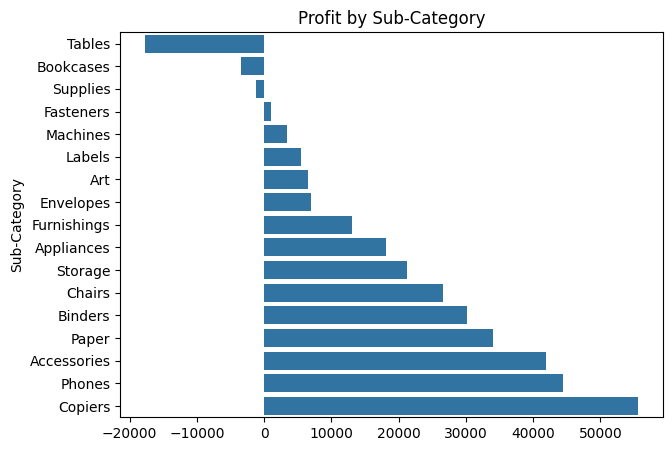

<Figure size 640x480 with 0 Axes>

In [51]:
sub_loss = df.groupby('Sub-Category')['Profit'].sum().sort_values()

plt.figure(figsize=(7,5))
sns.barplot(x=sub_loss.values, y=sub_loss.index)
plt.title("Profit by Sub-Category")
plt.show()

plt.savefig("visualizations/subcategory_profit.png", dpi=300, bbox_inches='tight')


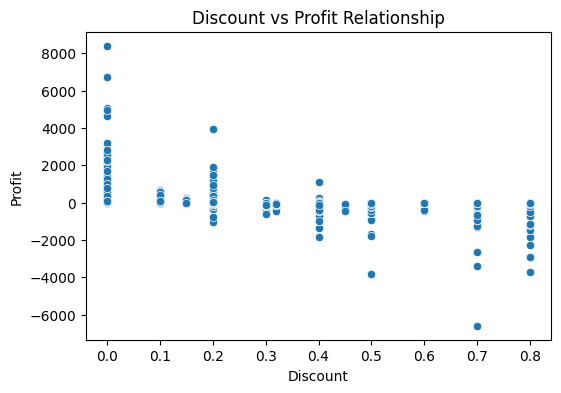

<Figure size 640x480 with 0 Axes>

In [52]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='Discount', y='Profit')
plt.title("Discount vs Profit Relationship")
plt.show()

plt.savefig("visualizations/discount_vs_profit.png", dpi=300, bbox_inches='tight')


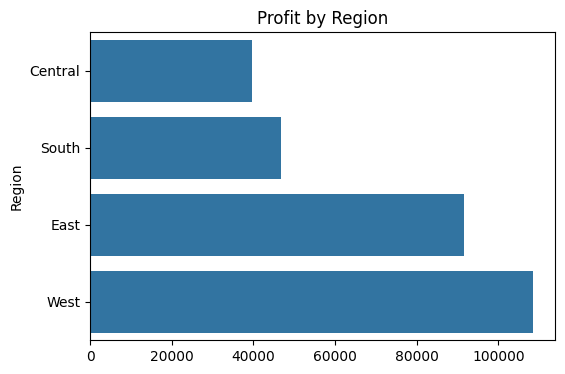

<Figure size 640x480 with 0 Axes>

In [53]:
region_profit = df.groupby('Region')['Profit'].sum().sort_values()

plt.figure(figsize=(6,4))
sns.barplot(x=region_profit.values, y=region_profit.index)
plt.title("Profit by Region")
plt.show()

plt.savefig("visualizations/profit_by_region.png", dpi=300, bbox_inches='tight')


In [54]:
current_date = df['Order Date'].max()

rfm = df.groupby('Customer Name').agg({
    'Order Date': lambda x: (current_date - x.max()).days,
    'Order ID': 'nunique',
    'Sales': 'sum'
}).reset_index()

rfm.columns = ['Customer Name','Recency','Frequency','Monetary']

rfm.head()


,Customer Name,Recency,Frequency,Monetary
0,Aaron Bergman,415,3,886.156
1,Aaron Hawkins,12,7,1744.700
2,Aaron Smayling,88,7,3050.692
3,Adam Bellavance,54,8,7755.620
4,Adam Hart,34,10,3250.337


In [55]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method="first"), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

rfm['RFM_Score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

rfm.head()


,Customer Name,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
0,Aaron Bergman,415,3,886.156,1,1,1,111
1,Aaron Hawkins,12,7,1744.700,4,3,2,432
2,Aaron Smayling,88,7,3050.692,2,3,3,233
3,Adam Bellavance,54,8,7755.620,3,3,4,334
4,Adam Hart,34,10,3250.337,3,4,3,343


In [56]:
rfm.columns


Index(['Customer Name', 'Recency', 'Frequency', 'Monetary', 'R_score',
       'F_score', 'M_score', 'RFM_Score'],
      dtype='object')

In [57]:
def segment_customer(row):
    if row['RFM_Score'] in ['444','443','434','344']:
        return 'VIP Customers'
    elif row['RFM_Score'][0] == '4':
        return 'Recent Customers'
    elif row['RFM_Score'][1] == '4':
        return 'Loyal Customers'
    elif row['RFM_Score'][2] == '4':
        return 'Big Spenders'
    else:
        return 'At Risk'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)
rfm.head()


,Customer Name,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
0,Aaron Bergman,415,3,886.156,1,1,1,111,At Risk
1,Aaron Hawkins,12,7,1744.700,4,3,2,432,Recent Customers
2,Aaron Smayling,88,7,3050.692,2,3,3,233,At Risk
3,Adam Bellavance,54,8,7755.620,3,3,4,334,Big Spenders
4,Adam Hart,34,10,3250.337,3,4,3,343,Loyal Customers


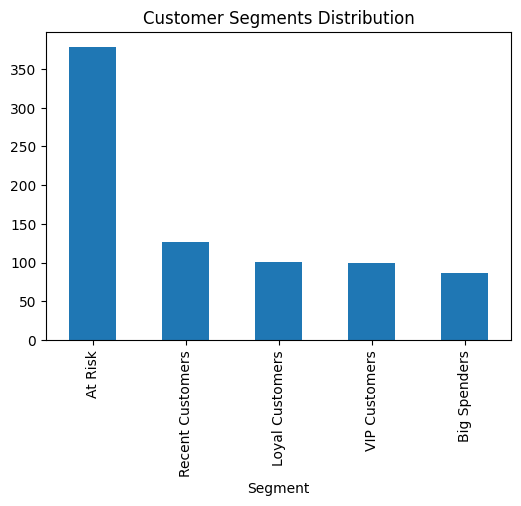

<Figure size 640x480 with 0 Axes>

In [58]:
import matplotlib.pyplot as plt

rfm['Segment'].value_counts().plot(kind='bar', figsize=(6,4))
plt.title("Customer Segments Distribution")
plt.show()

plt.savefig("visualizations/customer_segments.png", dpi=300, bbox_inches='tight')
